<a href="https://colab.research.google.com/github/MartinDelhaye/Projet-ML-Mobile/blob/main/regression_one_neuron/regression_one_neuron.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import modules

In [478]:
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam
from torch.optim import SGD
from sklearn.model_selection import train_test_split

import torchvision
import torchvision.transforms.v2 as transforms

import numpy as np

Build the dataset with noisy points, according to the underlying equation $y = m.x+b$. The parameters can be changed to see the learning adaptability of the model

In [479]:
# Generate data points
X = np.random.randn(500, 1)
m = 4
b = 1.5
noise = 10
y = m * X[:, 0] + b + np.random.normal(scale=noise, size=500)

# Reshape and split the data
y = y.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

Plot the data

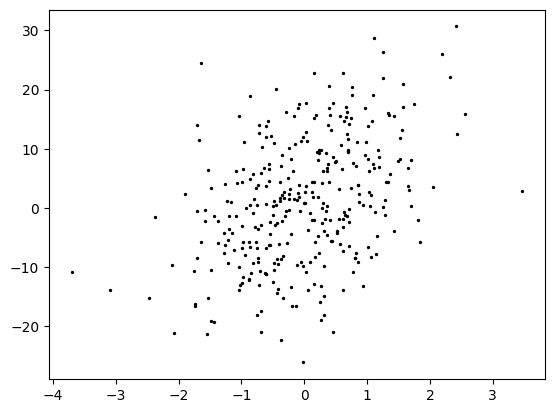

In [480]:
plt.scatter(X_train, y_train, c='k', s=2)
plt.show()

The inherited RegressionData class will help us handle the dataset for pytorch data loader

In [481]:
class RegressionData(Dataset):
  def __init__(self, X: np.ndarray, y: np.ndarray) -> None:
    self.X = torch.from_numpy(X.astype(np.float32))
    self.y = torch.from_numpy(y.astype(np.float32))
    self.len = self.X.shape[0]
  def __getitem__(self, index: int) -> tuple:
    return self.X[index], self.y[index]
  def __len__(self) -> int:
    return self.len

In [482]:
train_data = RegressionData(X_train, y_train)
train_loader = DataLoader(train_data, batch_size=50, shuffle=True)

Let's build the one-neuron model!

In [483]:
layers = [
    nn.Flatten(),
    nn.Linear(1, 1),
]
model = nn.Sequential(*layers)
print(model)
model = torch.compile(model)
loss_function = nn.MSELoss()
# optimizer = Adam(model.parameters(), lr=0.1) #version de base du cours
optimizer = SGD(model.parameters(), lr=0.1)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=1, out_features=1, bias=True)
)


We run the optimization process as usual

In [484]:
losses = []
loss = 0
epochs = 10
for epoch in range(epochs):
    loss = 0
    for i, (x, y) in enumerate(train_loader):
        output = model(x)
        optimizer.zero_grad()
        batch_loss = loss_function(output, y)
        batch_loss.backward()
        optimizer.step()

        loss += batch_loss.item()
    losses.append(loss)
    print(f'Epoch:{epoch + 1:5d}' + ' | ' f'Train Loss: {loss:.4f}')


Epoch:    1 | Train Loss: 718.9906
Epoch:    2 | Train Loss: 656.3312
Epoch:    3 | Train Loss: 653.0328
Epoch:    4 | Train Loss: 663.5535
Epoch:    5 | Train Loss: 647.4988
Epoch:    6 | Train Loss: 656.0987
Epoch:    7 | Train Loss: 656.0253
Epoch:    8 | Train Loss: 649.8272
Epoch:    9 | Train Loss: 645.1470
Epoch:   10 | Train Loss: 653.5105


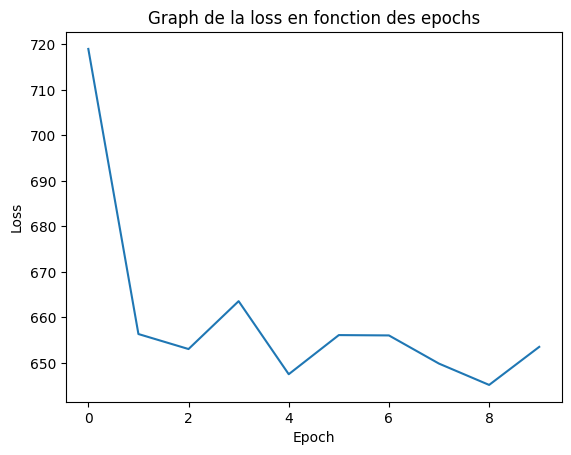

In [485]:
plt.plot(losses)
plt.title("Graph de la loss en fonction des epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()


What are the parameters obtained by the model?

In [486]:
for name, param in model.named_parameters():
    if param.requires_grad:
        print(name, param.data)

_orig_mod.1.weight tensor([[4.4916]])
_orig_mod.1.bias tensor([1.3495])
